<a href="https://colab.research.google.com/github/engenheirork/calculo-numerico-computacional-2026/blob/main/atividade_aula04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A função escolhida foi:

f(x) = cos(x) - x

Intervalo analisado: [0,1]

In [5]:
def f(x):
    return np.cos(x) - x

def df(x):
    return -np.sin(x) - 1

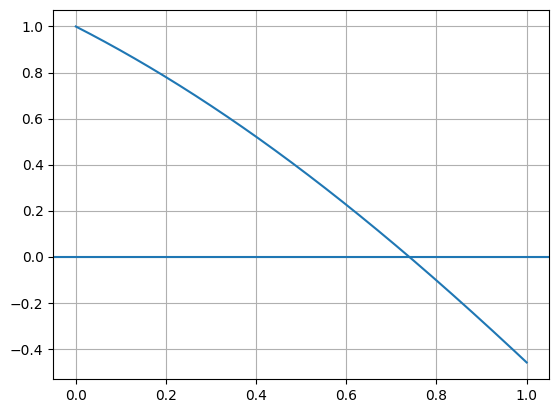

In [6]:
x = np.linspace(0, 1, 400)
y = f(x)

plt.plot(x, y)
plt.axhline(0)
plt.grid()
plt.show()

Pelo gráfico, a raiz parece estar entre 0,7 e 0,8.
No intervalo [0,1], a função parece ter apenas uma raiz.

In [7]:
def bisseccao(f, a, b, n):
    dados = []

    for i in range(1, n + 1):
        c = (a + b) / 2
        fc = f(c)

        dados.append([i, a, b, c, fc])

        if f(a) * fc < 0:
            b = c
        else:
            a = c

    tabela = pd.DataFrame(dados, columns=['Iteração', 'a', 'b', 'c', 'f(c)'])
    return tabela

In [8]:
tabela_biss = bisseccao(f, 0, 1, 10)
tabela_biss

,Iteração,a,b,c,f(c)
0,1,0.000000,1.000000,0.500000,0.377583
1,2,0.500000,1.000000,0.750000,-0.018311
2,3,0.500000,0.750000,0.625000,0.185963
3,4,0.625000,0.750000,0.687500,0.085335
4,5,0.687500,0.750000,0.718750,0.033879
5,6,0.718750,0.750000,0.734375,0.007875
6,7,0.734375,0.750000,0.742188,-0.005196
7,8,0.734375,0.742188,0.738281,0.001345
8,9,0.738281,0.742188,0.740234,-0.001924
9,10,0.738281,0.740234,0.739258,-0.000289


Após 10 iterações, foi obtida uma aproximação inicial da raiz.

In [9]:
raiz_biss = tabela_biss.iloc[-1]['c']
print(raiz_biss)

0.7392578125


A bissecção foi útil para localizar a raiz de forma segura, dividindo o intervalo ao meio em cada iteração.

In [10]:
def newton(f, df, x0, n):
    dados = []
    x = x0

    for i in range(1, n + 1):
        fx = f(x)
        dfx = df(x)

        x_novo = x - fx / dfx
        erro = abs(x_novo - x)

        dados.append([i, x, fx, erro])
        x = x_novo

    tabela = pd.DataFrame(dados, columns=['Iteração', 'x_n', 'f(x_n)', 'erro'])
    return tabela

In [11]:
tabela_newton = newton(f, df, raiz_biss, 10)
tabela_newton

,Iteração,x_n,f(x_n),erro
0,1,0.739258,-2.890091e-04,1.726727e-04
1,2,0.739085,-1.101707e-08,6.582812e-09
2,3,0.739085,0.000000e+00,0.000000e+00
3,4,0.739085,0.000000e+00,0.000000e+00
4,5,0.739085,0.000000e+00,0.000000e+00
5,6,0.739085,0.000000e+00,0.000000e+00
6,7,0.739085,0.000000e+00,0.000000e+00
7,8,0.739085,0.000000e+00,0.000000e+00
8,9,0.739085,0.000000e+00,0.000000e+00
9,10,0.739085,0.000000e+00,0.000000e+00


## Resultado do método de Newton

Usando como chute inicial o valor encontrado pela bissecção, o método de Newton gerou aproximações mais rápidas da raiz.

In [12]:
raiz_newton = tabela_newton.iloc[-1]['x_n']
print("Aproximação da raiz por Newton:", raiz_newton)

Aproximação da raiz por Newton: 0.7390851332151607


O método de Newton foi mais rápido porque usa a derivada da função para encontrar aproximações melhores da raiz.

In [13]:
print("Raiz pela bissecção:", raiz_biss)
print("Raiz por Newton:", raiz_newton)
print("Iterações da bissecção:", len(tabela_biss))
print("Iterações de Newton:", len(tabela_newton))

Raiz pela bissecção: 0.7392578125
Raiz por Newton: 0.7390851332151607
Iterações da bissecção: 10
Iterações de Newton: 10


Agora vou testar o método de Newton com diferentes valores iniciais.

In [14]:
chutes = [0, 1, 10]

for chute in chutes:
    tabela_teste = newton(f, df, chute, 10)
    raiz_teste = tabela_teste.iloc[-1]['x_n']
    print("Chute inicial:", chute)
    print("Aproximação final:", raiz_teste)
    print()

Chute inicial: 0
Aproximação final: 0.7390851332151607

Chute inicial: 1
Aproximação final: 0.7390851332151607

Chute inicial: 10
Aproximação final: -142.46844918750787



Os testes mostraram que o método de Newton depende do chute inicial. Quando o valor inicial está mais perto da raiz, a convergência costuma ser melhor.

O método de Newton costuma convergir mais rápido porque usa a derivada da função para melhorar a aproximação da raiz.

O método da bissecção pode ser preferível quando se quer mais segurança, já que ele funciona bem quando existe mudança de sinal no intervalo.

Em um problema real de engenharia, eu usaria Newton quando tivesse um bom chute inicial e a derivada da função. Se quisesse mais segurança, usaria a bissecção.

Nesta atividade, foi possível comparar o método da Bissecção com o método de Newton para encontrar a raiz da função escolhida.

A bissecção foi mais segura, enquanto Newton foi mais rápido. Assim, deu para perceber que cada método tem sua vantagem, dependendo da situação.